In [15]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [16]:
df = pd.read_csv('./archive/Crop_recommendation.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (2200, 8)

First few rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), st

In [17]:
# Cell 3: Check for Missing Values and Duplicates
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows: 0
Shape after removing duplicates: (2200, 8)


Crop Labels:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Number of unique crops: 22

Crop list:
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


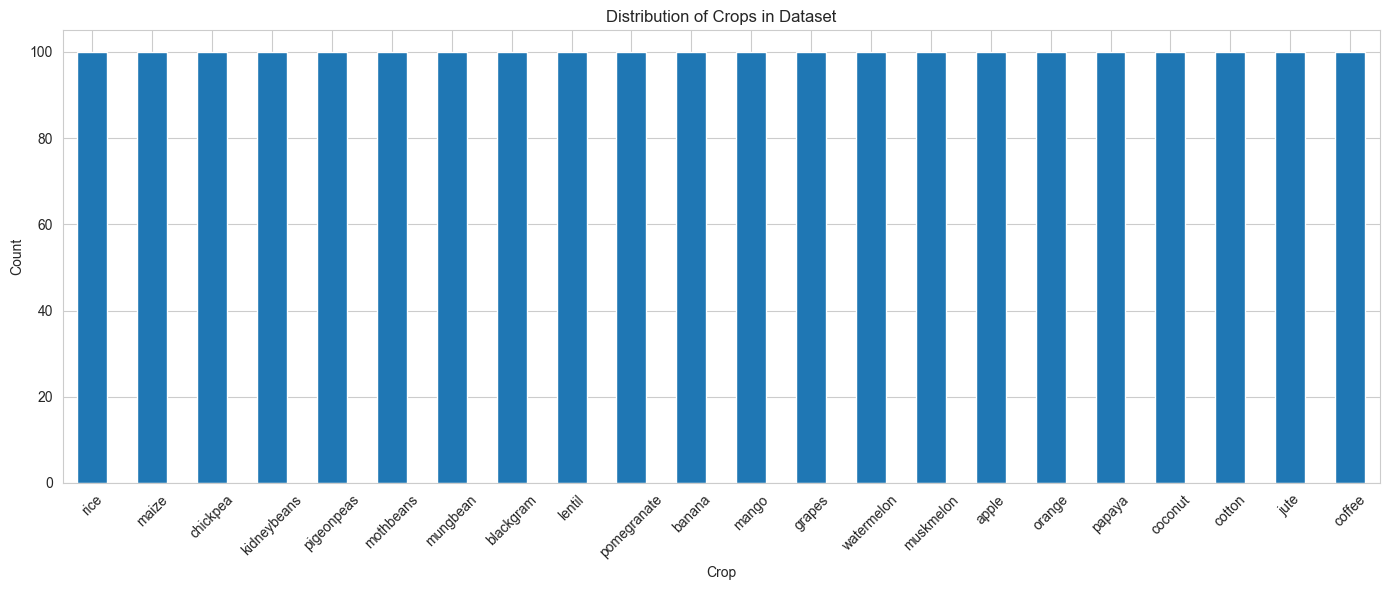

In [18]:
# Cell 4: Analyze Crop Distribution
print("Crop Labels:")
print(df['label'].value_counts())
print("\nNumber of unique crops:", df['label'].nunique())
print("\nCrop list:")
print(sorted(df['label'].unique()))

# Visualize crop distribution
plt.figure(figsize=(14, 6))
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Crops in Dataset')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

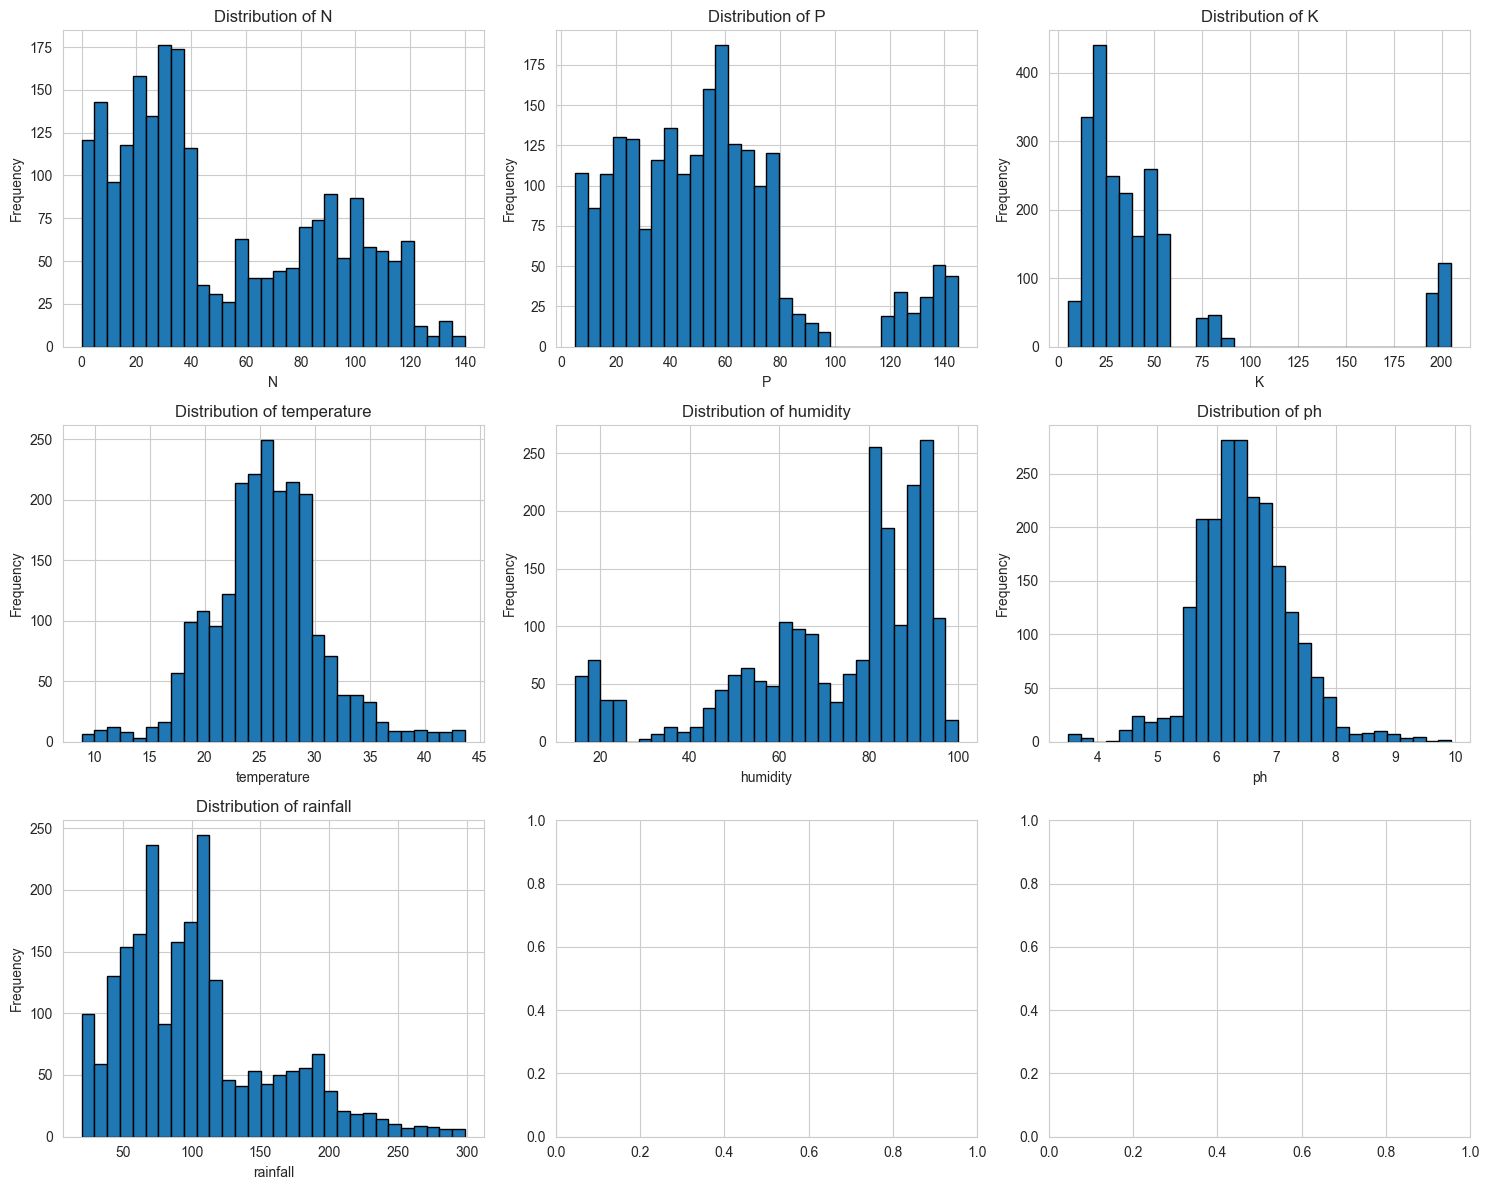

In [19]:
# Cell 5: Analyze Feature Distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

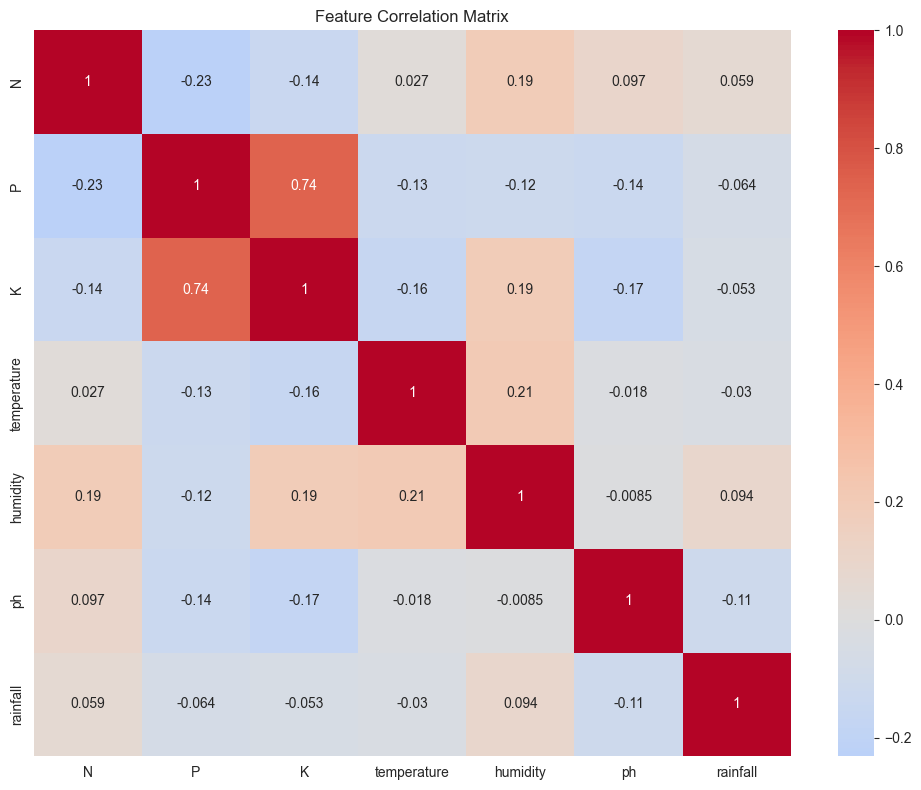

In [20]:
# Cell 6: Correlation Analysis
plt.figure(figsize=(10, 8))
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
# Cell 7: Analyze Feature Ranges per Crop
# This helps understand ideal conditions for each crop
sample_crops = df['label'].unique()[:5]  # Sample 5 crops

for crop in sample_crops:
    crop_data = df[df['label'] == crop]
    print(f"\n=== {crop} ===")
    print(crop_data[features].describe().loc[['mean', 'min', 'max']])


=== rice ===
          N      P      K  temperature   humidity        ph    rainfall
mean  79.89  47.58  39.87    23.689332  82.272822  6.425471  236.181114
min   60.00  35.00  35.00    20.045414  80.122675  5.005307  182.561632
max   99.00  60.00  45.00    26.929951  84.969072  7.868475  298.560117

=== maize ===
           N      P      K  temperature   humidity        ph    rainfall
mean   77.76  48.44  19.79    22.389204  65.092249  6.245190   84.766988
min    60.00  35.00  15.00    18.041855  55.282204  5.513698   60.651715
max   100.00  60.00  25.00    26.549864  74.829137  6.995844  109.751538

=== chickpea ===
          N      P      K  temperature   humidity        ph   rainfall
mean  40.09  67.79  79.92    18.872847  16.860439  7.336957  80.058977
min   20.00  55.00  75.00    17.024985  14.258040  5.988993  65.113656
max   60.00  80.00  85.00    20.995022  19.969789  8.868741  94.781896

=== kidneybeans ===
          N      P      K  temperature   humidity        ph    rainf

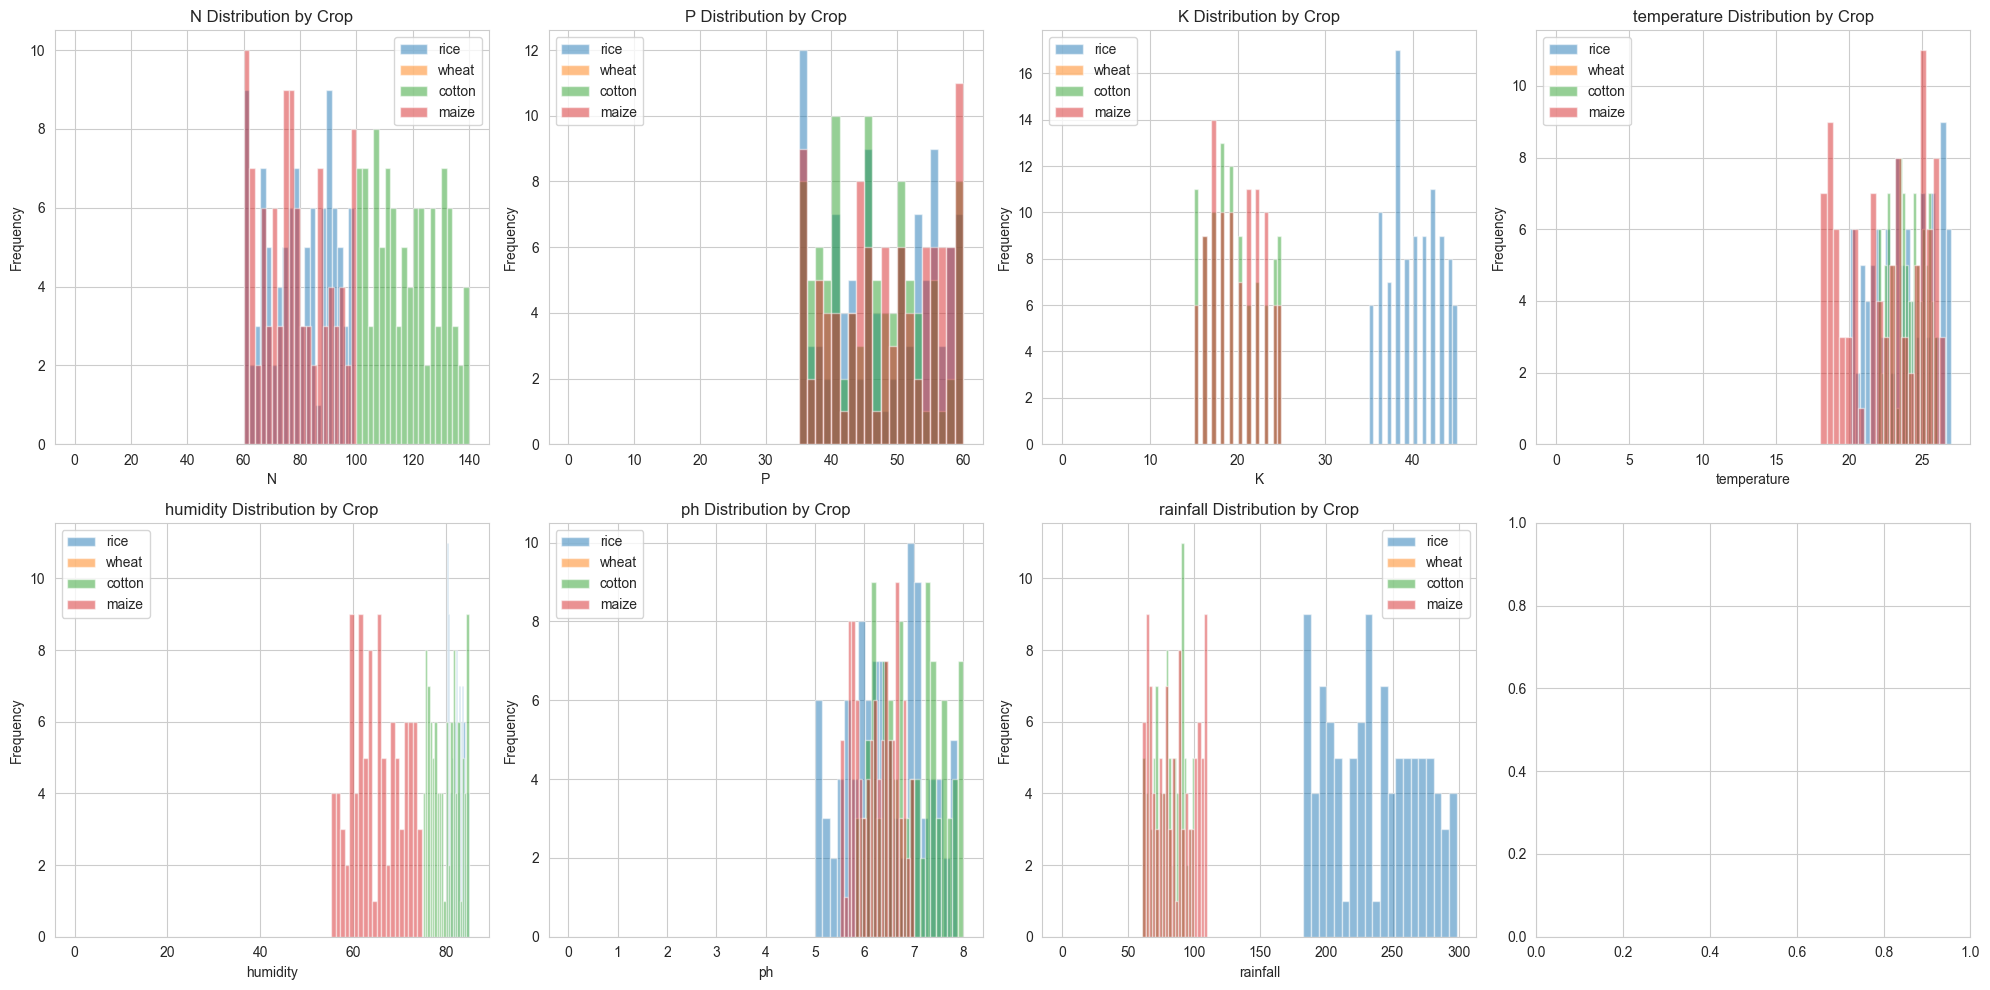

In [22]:
# Cell 8: Visualize Feature Ranges for Specific Crops
selected_crops = ['rice', 'wheat', 'cotton', 'maize']  # Adjust based on your dataset

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    for crop in selected_crops:
        crop_data = df[df['label'] == crop][feature]
        axes[idx].hist(crop_data, alpha=0.5, label=crop, bins=20)
    
    axes[idx].set_title(f'{feature} Distribution by Crop')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [23]:
# Cell 9: Prepare Data for Training
# Separate features and target
X = df[features]
y = df['label']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label Encoding:")
for idx, crop in enumerate(label_encoder.classes_):
    print(f"{idx}: {crop}")

# Save label encoder for later use
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

Label Encoding:
0: apple
1: banana
2: blackgram
3: chickpea
4: coconut
5: coffee
6: cotton
7: grapes
8: jute
9: kidneybeans
10: lentil
11: maize
12: mango
13: mothbeans
14: mungbean
15: muskmelon
16: orange
17: papaya
18: pigeonpeas
19: pomegranate
20: rice
21: watermelon


In [24]:
# Cell 10: Split Dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (1540, 7)
Validation set size: (330, 7)
Test set size: (330, 7)


In [25]:
# Cell 11: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler for later use
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Feature scaling completed")
print("\nScaled feature ranges:")
print(pd.DataFrame(X_train_scaled, columns=features).describe())

Feature scaling completed

Scaled feature ranges:
                  N             P             K   temperature      humidity  \
count  1.540000e+03  1.540000e+03  1.540000e+03  1.540000e+03  1.540000e+03   
mean   4.844610e-17  5.075305e-17  2.999044e-17  3.644992e-16 -1.372639e-16   
std    1.000325e+00  1.000325e+00  1.000325e+00  1.000325e+00  1.000325e+00   
min   -1.362949e+00 -1.470839e+00 -8.506796e-01 -3.270373e+00 -2.566713e+00   
25%   -7.956821e-01 -7.703262e-01 -5.548155e-01 -5.530426e-01 -5.065252e-01   
50%   -3.634788e-01 -6.981390e-02 -3.181243e-01 -1.540322e-02  4.090516e-01   
75%    9.061184e-01  4.479561e-01 -2.535978e-03  5.647645e-01  8.273221e-01   
max    2.418830e+00  2.793149e+00  3.094174e+00  3.469444e+00  1.281160e+00   

                 ph      rainfall  
count  1.540000e+03  1.540000e+03  
mean  -9.588290e-16 -9.227828e-17  
std    1.000325e+00  1.000325e+00  
min   -3.821764e+00 -1.513004e+00  
25%   -6.623133e-01 -7.034297e-01  
50%   -4.722378e-02 -1

In [26]:
# Cell 12: Decision Tree Model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_val_pred_dt = dt_model.predict(X_val_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)

# Accuracy
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
val_acc_dt = accuracy_score(y_val, y_val_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

print("Decision Tree Results:")
print(f"Training Accuracy: {train_acc_dt:.4f}")
print(f"Validation Accuracy: {val_acc_dt:.4f}")
print(f"Test Accuracy: {test_acc_dt:.4f}")

Decision Tree Results:
Training Accuracy: 0.9903
Validation Accuracy: 0.9727
Test Accuracy: 0.9758



Classification Report (Test Set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       0.88      1.00      0.94        15
   blackgram       1.00      0.93      0.97        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       0.79      1.00      0.88        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      0.73      0.85        15
       mango       1.00      1.00      1.00        15
   mothbeans       0.94      1.00      0.97        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00   

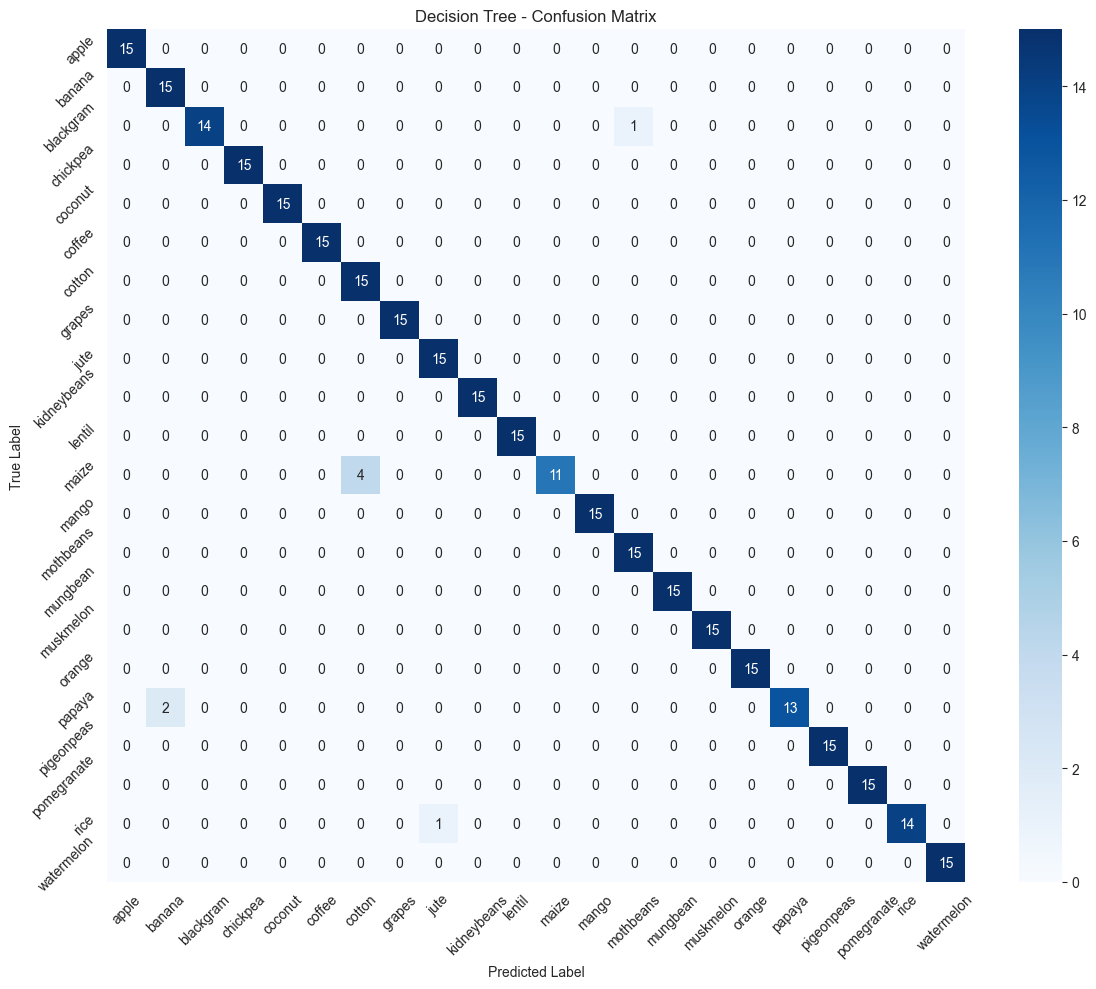

In [27]:
# Cell 13: Decision Tree - Detailed Evaluation
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_dt, 
                          target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_test_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


Feature Importance:
       feature  importance
6     rainfall    0.358955
1            P    0.229446
4     humidity    0.164234
2            K    0.142950
0            N    0.095822
5           ph    0.006850
3  temperature    0.001742


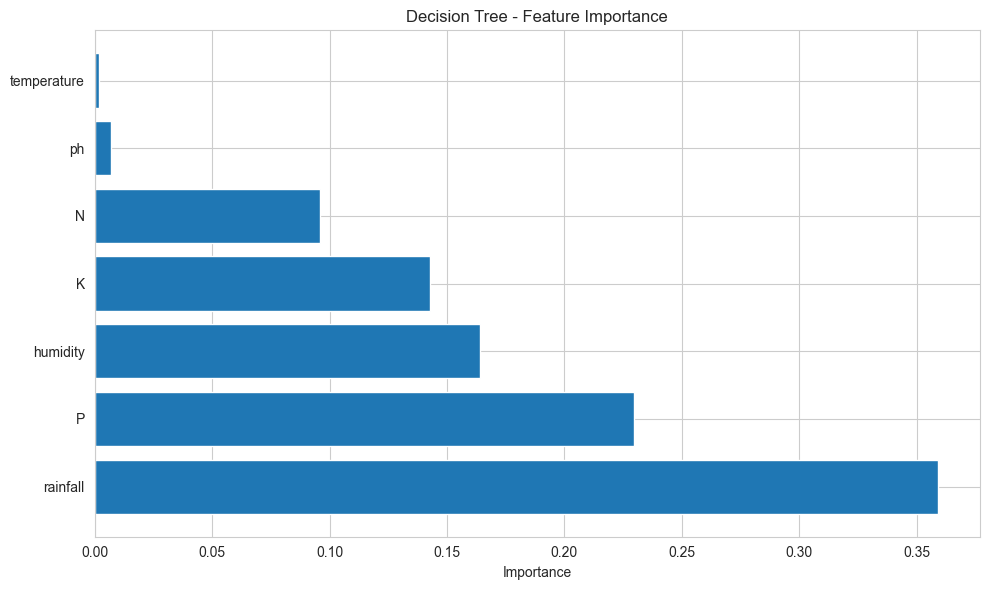

In [28]:
# Cell 14: Feature Importance (Decision Tree)
feature_importance_dt = pd.DataFrame({
    'feature': features,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_dt)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_dt['feature'], feature_importance_dt['importance'])
plt.xlabel('Importance')
plt.title('Decision Tree - Feature Importance')
plt.tight_layout()
plt.show()

In [29]:
# Cell 15: Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Accuracy
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("Random Forest Results:")
print(f"Training Accuracy: {train_acc_rf:.4f}")
print(f"Validation Accuracy: {val_acc_rf:.4f}")
print(f"Test Accuracy: {test_acc_rf:.4f}")

Random Forest Results:
Training Accuracy: 0.9981
Validation Accuracy: 0.9909
Test Accuracy: 0.9970



Classification Report (Test Set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00   

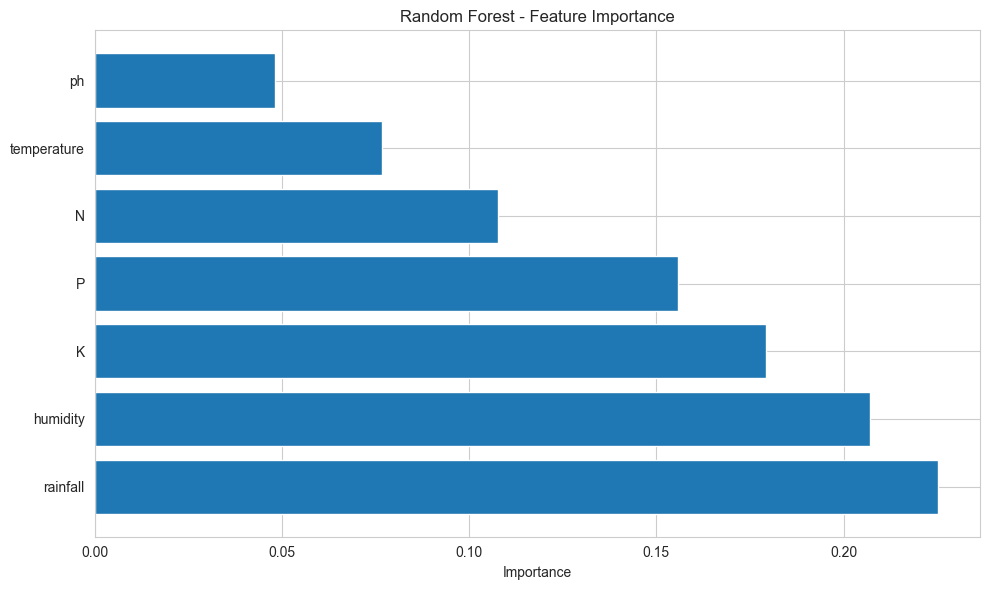

In [30]:
# Cell 16: Random Forest - Detailed Evaluation
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf,
                          target_names=label_encoder.classes_))

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_rf)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'])
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

In [39]:
# Cell 17: Import TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [40]:
# Cell 18: Prepare Data for CNN
# Convert labels to categorical (one-hot encoding)
num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Reshape for CNN (add channel dimension)
X_train_cnn = X_train_scaled.reshape(-1, 7, 1)
X_val_cnn = X_val_scaled.reshape(-1, 7, 1)
X_test_cnn = X_test_scaled.reshape(-1, 7, 1)

print("CNN Input Shape:", X_train_cnn.shape)
print("Number of classes:", num_classes)

CNN Input Shape: (1540, 7, 1)
Number of classes: 22


In [36]:
# Cell 19: Build CNN Model
def create_cnn_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.Conv1D(64, 3, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = create_cnn_model((7, 1), num_classes)
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 5, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 0, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,158 (199.84 KB)

 Trainable params: 51,158 (199.84 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Cell 20: Compile and Train CNN
# Rebuild your CNN model with kernel_size=2
cnn_model = keras.Sequential([
    layers.Conv1D(64, kernel_size=2, activation='relu', 
                  input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=2, activation='relu'),  # Changed from 3 to 2
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_train_cat.shape[1], activation='softmax')
])

# Now compile and train
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1753 - loss: 2.8172 - val_accuracy: 0.2485 - val_loss: 2.4336
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3877 - loss: 2.0738 - val_accuracy: 0.6121 - val_loss: 1.4830
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5909 - loss: 1.3266 - val_accuracy: 0.7970 - val_loss: 0.8262
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7091 - loss: 0.9003 - val_accuracy: 0.8879 - val_loss: 0.5515
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7792 - loss: 0.6761 - val_accuracy: 0.9000 - val_loss: 0.4113
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8221 - loss: 0.5417 - val_accuracy: 0.9091 - val_loss: 0.3373
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8403 - loss: 0.4592 - val_accuracy: 0.9242 - val_loss: 0.2914
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8701 - loss: 0.3928 - val_accuracy: 0.9121 - val_loss


CNN Test Accuracy: 0.9818


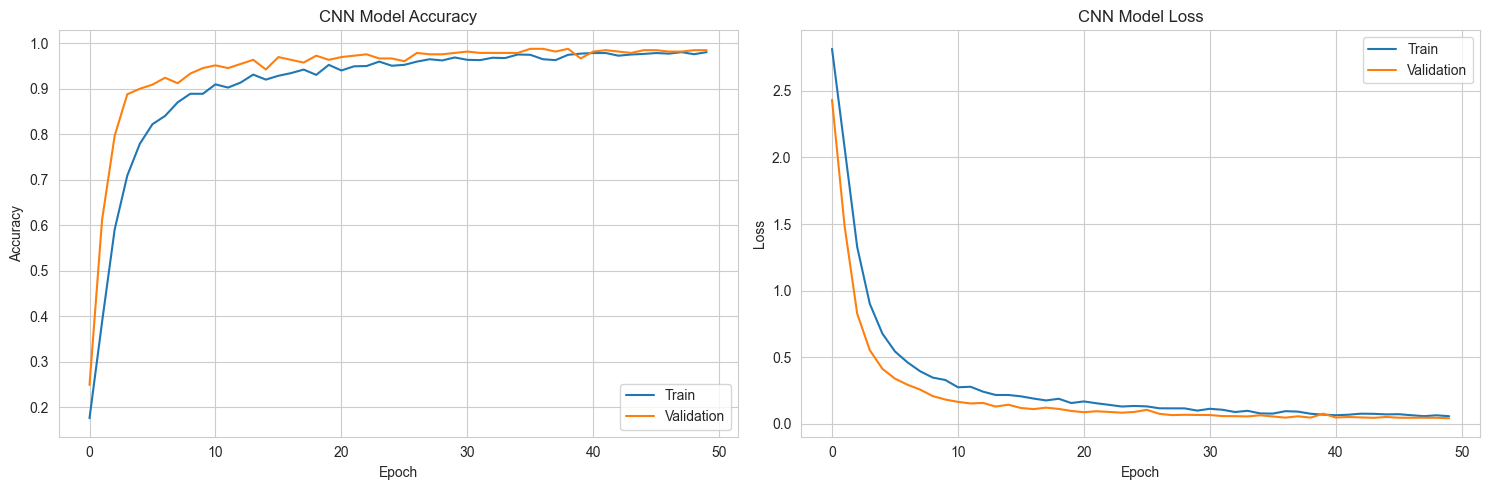

In [45]:
# Cell 21: Evaluate CNN
# Test accuracy
test_loss, test_acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"\nCNN Test Accuracy: {test_acc_cnn:.4f}")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('CNN Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('CNN Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Model Comparison:
           Model  Train Accuracy  Validation Accuracy  Test Accuracy
0  Decision Tree        0.990260             0.972727       0.975758
1  Random Forest        0.998052             0.990909       0.996970
2            CNN        0.980519             0.984848       0.981818


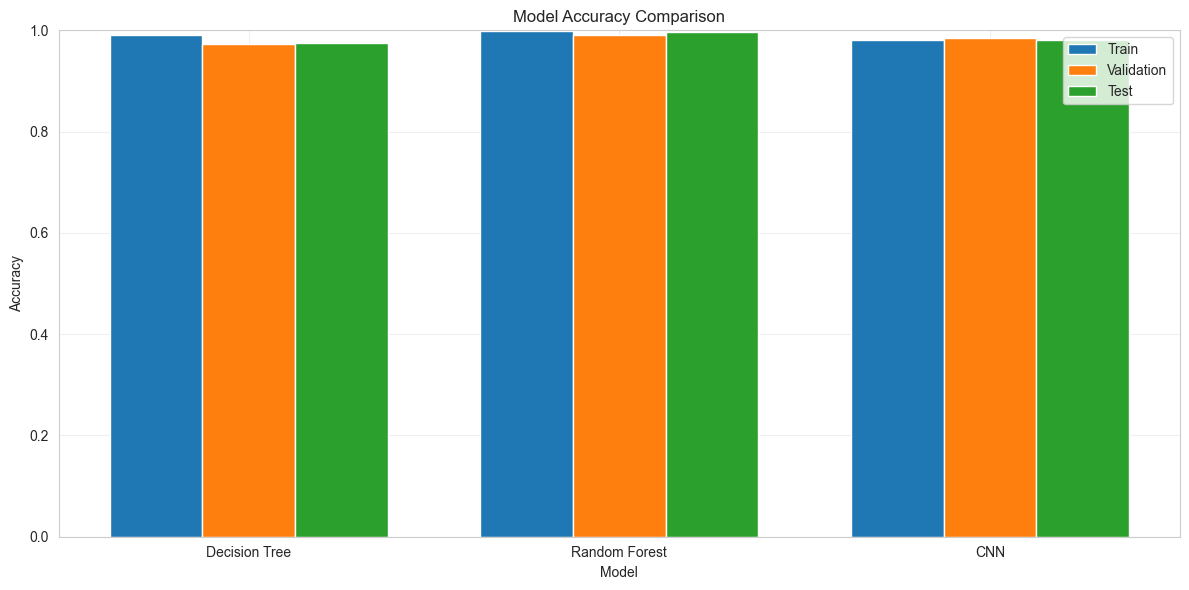

In [46]:
# Cell 22: Model Comparison
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'CNN'],
    'Train Accuracy': [train_acc_dt, train_acc_rf, history.history['accuracy'][-1]],
    'Validation Accuracy': [val_acc_dt, val_acc_rf, history.history['val_accuracy'][-1]],
    'Test Accuracy': [test_acc_dt, test_acc_rf, test_acc_cnn]
})

print("Model Comparison:")
print(results)

# Visualize comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(results))
width = 0.25

plt.bar(x - width, results['Train Accuracy'], width, label='Train')
plt.bar(x, results['Validation Accuracy'], width, label='Validation')
plt.bar(x + width, results['Test Accuracy'], width, label='Test')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(x, results['Model'])
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Cell 23: Convert Decision Tree to TensorFlow Model
# We'll create a simple Neural Network that mimics the decision tree

# Use the best sklearn model's predictions as training labels
best_sklearn_model = dt_model  # or rf_model if better

# Create a neural network
def create_dense_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

dense_model = create_dense_model(7, num_classes)
dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_dense = dense_model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate
test_loss_dense, test_acc_dense = dense_model.evaluate(X_test_scaled, y_test_cat)
print(f"\nDense Model Test Accuracy: {test_acc_dense:.4f}")

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2682 - loss: 2.5021 - val_accuracy: 0.5727 - val_loss: 2.6377
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6221 - loss: 1.4699 - val_accuracy: 0.6576 - val_loss: 2.1855
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7351 - loss: 1.0176 - val_accuracy: 0.7455 - val_loss: 1.6499
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8208 - loss: 0.7074 - val_accuracy: 0.8515 - val_loss: 1.1263
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8558 - loss: 0.5296 - val_accuracy: 0.8970 - val_loss: 0.7340
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8838 - loss: 0.4382 - val_accuracy: 0.9242 - val_loss: 0.4899
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.3692 - val_accuracy: 0.9424 - val_loss: 0.3376
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9097 - loss: 0.3067 - val_accuracy: 0.9697 - v